In [1]:
from astropy.io import fits
import clevar
import sys

sys.path.insert(0, "/global/homes/l/lettieri/gcrcatalogs-new/gcr-catalogs")
sys.path.insert(0, "/global/homes/l/lettieri/gcr-catalogs")
sys.path.insert(0, "../ame")

from clevar.match_metrics.recovery import ClCatalogFuncs as r_cf
from clevar.match_metrics.distances import ClCatalogFuncs as d_cf
from clevar.match_metrics.scaling import ClCatalogFuncs as s_cf
import clevar.match_metrics.scaling as scaling

import pandas as pd
from astropy.table import unique, Table
import astropy
from matplotlib import pyplot as plt
import numpy as np
from numcosmo_py import Ncm, Nc
from numcosmo_py.external.pyssc import pyssc as PySS
from numcosmo_py.helper import npa_to_seq
from numcosmo_py import sky_match
import time
from tqdm import tqdm
Ncm.cfg_init()
from time_model import PySLineModel, PySLineGauss

import GCRCatalogs
print('GCRCatalogs =', GCRCatalogs.__version__, '|' ,'GCR =', GCRCatalogs.GCR.__version__)
from GCR import GCRQuery
%load_ext autoreload
%autoreload 2

/global/homes/l/lettieri/.local/lib/python3.13/site-packages/hpgeom-0.0.0-py3.13-linux-x86_64.egg/hpgeom/_hpgeom.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


GCRCatalogs = 1.10.2 | GCR = 0.9.2


In [2]:
zmin = 0.0
zmax = 1.2
logMmin = 12.5
logMmax = 16.0
logRmin = 0
logRmax = 3 

# We are loading the cosmoDC2_redmapper catalalog with richness
redmapper_cat = GCRCatalogs.load_catalog("cosmoDC2_v1.1.4_redmapper_v0.8.1")
image_cat = GCRCatalogs.load_catalog("cosmoDC2_v1.1.4_image")

# Taking some important information about the fiducial cosmological model and survey region
redmapper_cosmology = redmapper_cat.cosmology
sky_area = redmapper_cat.sky_area

# Listing all quantities in the choosen catalog
#np.sort(redmapper_cat.list_all_quantities())
#print(np.sort(redmapper_cat.list_all_quantities()))



#image_cat['halo_mass'].size()

data_redmapper = redmapper_cat.get_quantities(
    ["cluster_id", "redshift", "redshift_err", "richness", "richness_err", "ra", "dec"],
    filters=[
        f"redshift > {zmin}",
        f"redshift < {zmax}",
        f"richness > {10**logRmin}",
        f"richness < {10**logRmax}",
    ],
)

data_dc2 = image_cat.get_quantities(
    ["halo_id" , "redshift_true", "halo_mass", "ra_true", "dec_true"],
    filters=[
        f"redshift_true > {zmin}",
        f"redshift_true < {zmax}",
        f"halo_mass > {10**logMmin}",
        f"halo_mass < {10**logMmax}",
        f"is_central == {True}", 
    ],
)

table_halos = Table(data_dc2)
table_halos['halo_mass'] = np.log10(table_halos['halo_mass'])
table_redmapper = Table(data_redmapper)

In [3]:
area = 4109.3
cosmo = Nc.HICosmoDEXcdm()
cosmo.param_set_by_name("Omegax", redmapper_cosmology.Ode0)
cosmo.param_set_by_name("H0", redmapper_cosmology.H0.value)
cosmo.param_set_by_name("Omegab", redmapper_cosmology.Ob0)
cosmo.param_set_by_name("Omegac", redmapper_cosmology.Odm0)  # 0.2603
cosmo.param_set_by_name("w", -1.0)  # -1.0

prim = Nc.HIPrimPowerLaw.new()
prim.param_set_by_name("ln10e10ASA", 3.059917486993207)
prim.props.n_SA = redmapper_cosmology.n_s
reion = Nc.HIReionCamb.new()

cosmo.add_submodel(prim)
cosmo.add_submodel(reion)


reion = Nc.HIReionCamb.new()

cosmo.add_submodel(prim)
cosmo.add_submodel(reion)

dist = Nc.Distance.new(100.0)
dist.prepare(cosmo)

# 2D match time test

Processing Mass Thresholds: 100%|██████████| 12/12 [23:35<00:00, 117.94s/mass, Current Mass=1.40e+01] 

cessing k Nearest neighboors:   0%|          | 0/6 [23:35<?, ?k/s, Current k=20]

#----------------------------------------------------------------------------------
# Model fitting. Iterating using:
#  - solver:            NLOpt:ln-neldermead
#  - differentiation:   Numerical differentiation (forward)
#  Elapsed time: 00 days, 00:00:00.0007970
#  iteration            [000001]
#  function evaluations [000002]
#  gradient evaluations [000000]
#  degrees of freedom   [000010]
#  m2lnL     =      246.53444480554 (     246.53444 )
#  Fit parameters:
#     0.9                    0.2                   
#  Elapsed time: 00 days, 00:00:00.0009280
#  iteration            [000002]
#  function evaluations [000003]
#  gradient evaluations [000000]
#  degrees of freedom   [000010]
#  m2lnL     =     277.839228966465 (     277.83923 )
#  Fit parameters:
#     1                      0.2                   
#  Elapsed time: 00 days, 00:00:00.0010440
#  iteration            [000003]
#  function evaluations [000004]
#  gradient evaluations [000000]
#  degrees of freedom   [000010]
#  


cessing k Nearest neighboors:   0%|          | 0/6 [48:51<?, ?k/s, Current k=40]

#----------------------------------------------------------------------------------
# Model fitting. Iterating using:
#  - solver:            NLOpt:ln-neldermead
#  - differentiation:   Numerical differentiation (forward)
#  Elapsed time: 00 days, 00:00:00.0005860
#  iteration            [000001]
#  function evaluations [000002]
#  gradient evaluations [000000]
#  degrees of freedom   [000010]
#  m2lnL     =     259.387973599801 (     259.38797 )
#  Fit parameters:
#     0.9                    0.2                   
#  Elapsed time: 00 days, 00:00:00.0007260
#  iteration            [000002]
#  function evaluations [000003]
#  gradient evaluations [000000]
#  degrees of freedom   [000010]
#  m2lnL     =     304.022392303807 (     304.02239 )
#  Fit parameters:
#     1                      0.2                   
#  Elapsed time: 00 days, 00:00:00.0008980
#  iteration            [000003]
#  function evaluations [000004]
#  gradient evaluations [000000]
#  degrees of freedom   [000010]
#  


cessing k Nearest neighboors:   0%|          | 0/6 [1:18:20<?, ?k/s, Current k=60]

#----------------------------------------------------------------------------------
# Model fitting. Iterating using:
#  - solver:            NLOpt:ln-neldermead
#  - differentiation:   Numerical differentiation (forward)
#  Elapsed time: 00 days, 00:00:00.0013350
#  iteration            [000001]
#  function evaluations [000002]
#  gradient evaluations [000000]
#  degrees of freedom   [000010]
#  m2lnL     =     217.749357932398 (     217.74936 )
#  Fit parameters:
#     0.9                    0.2                   
#  Elapsed time: 00 days, 00:00:00.0014030
#  iteration            [000002]
#  function evaluations [000003]
#  gradient evaluations [000000]
#  degrees of freedom   [000010]
#  m2lnL     =     241.413899187908 (      241.4139 )
#  Fit parameters:
#     1                      0.2                   
#  Elapsed time: 00 days, 00:00:00.0014560
#  iteration            [000003]
#  function evaluations [000004]
#  gradient evaluations [000000]
#  degrees of freedom   [000010]
#  


cessing k Nearest neighboors:   0%|          | 0/6 [1:52:42<?, ?k/s, Current k=80]

#----------------------------------------------------------------------------------
# Model fitting. Iterating using:
#  - solver:            NLOpt:ln-neldermead
#  - differentiation:   Numerical differentiation (forward)
#  Elapsed time: 00 days, 00:00:00.0010390
#  iteration            [000001]
#  function evaluations [000002]
#  gradient evaluations [000000]
#  degrees of freedom   [000010]
#  m2lnL     =     131.596455177061 (     131.59646 )
#  Fit parameters:
#     0.9                    0.2                   
#  Elapsed time: 00 days, 00:00:00.0011910
#  iteration            [000002]
#  function evaluations [000003]
#  gradient evaluations [000000]
#  degrees of freedom   [000010]
#  m2lnL     =      145.06891879159 (     145.06892 )
#  Fit parameters:
#     1                      0.2                   
#  Elapsed time: 00 days, 00:00:00.0012790
#  iteration            [000003]
#  function evaluations [000004]
#  gradient evaluations [000000]
#  degrees of freedom   [000010]
#  


cessing k Nearest neighboors:   0%|          | 0/6 [2:31:22<?, ?k/s, Current k=100]

#----------------------------------------------------------------------------------
# Model fitting. Iterating using:
#  - solver:            NLOpt:ln-neldermead
#  - differentiation:   Numerical differentiation (forward)
#  Elapsed time: 00 days, 00:00:00.0013810
#  iteration            [000001]
#  function evaluations [000002]
#  gradient evaluations [000000]
#  degrees of freedom   [000010]
#  m2lnL     =     96.1133507834669 (     96.113351 )
#  Fit parameters:
#     0.9                    0.2                   
#  Elapsed time: 00 days, 00:00:00.0015670
#  iteration            [000002]
#  function evaluations [000003]
#  gradient evaluations [000000]
#  degrees of freedom   [000010]
#  m2lnL     =     103.838592274824 (     103.83859 )
#  Fit parameters:
#     1                      0.2                   
#  Elapsed time: 00 days, 00:00:00.0017420
#  iteration            [000003]
#  function evaluations [000004]
#  gradient evaluations [000000]
#  degrees of freedom   [000010]
#  

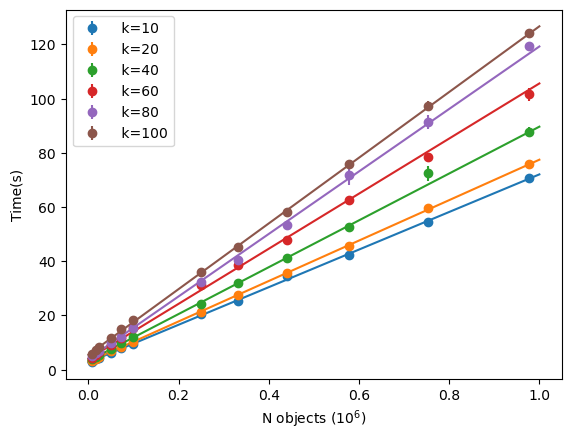

In [4]:
table_redmapper = Table(data_redmapper)
min_mass = [12.5, 12.6, 12.7, 12.8, 12.9,  13, 13.3, 13.4, 13.5, 13.7, 13.8, 14]
knearests = [10,20,40,60,80,100]

#min_mass = [13.3, 13.4, 13.5, 13.7, 13.8, 14]
#knearests = [80,100]
alphas = []
alphas_err = []
a_s = []
a_s_err = []
halo_coordinates = {"RA":"ra_true" , "DEC":"dec_true" , "z":"redshift_true", "ID":"ids"}
halo_properties  = {"halo_mass":"mass","halo_id":"halo_id"}

detections_coordinates =  {"RA":"ra" , "DEC":"dec" , "z":"redshift"}
detections_properties  = {"richness":"R" , "redshift_err":"z_err" , "richness_err":"R_err","cluster_id":"cluster_id"}


pbar = tqdm(min_mass, desc="Processing Mass Thresholds", unit="mass")
pbar_k = tqdm(knearests, desc="Processing k Nearest neighboors", unit="k")


for k in knearests:
    pbar_k.set_postfix({"Current k": f"{k}"})
    mean_time_halo_m = []
    mean_time_halo_b = []
    mean_time_halo_c = []
    mean_time_halo = []
    std_time_halo_m  = []
    std_time_halo_b  = []
    std_time_halo_c  = []
    std_time_halo = []
    size_halo = []
    
    for mass in pbar:
        # Update the progress bar suffix with the current mass value
        pbar.set_postfix({"Current Mass": f"{mass:.2e}"})
        
        reduced_halos = table_halos[table_halos['halo_mass'] >= mass]
        size_halo.append(len(reduced_halos['halo_mass']))
    
        halos = sky_match.SkyMatch(
            query_data=reduced_halos, 
            query_coordinates=halo_coordinates,
            match_data=table_redmapper,
            match_coordinates=detections_coordinates
        )
    
        detections = halos.invert_query_match()
        time_match_m, time_match_b, time_match_c, time_match = [], [], [], []
        for i in range(5):
            start = time.perf_counter()
            # Match phase
            start_m = time.perf_counter()
            halos_matched = halos.match_2d(cosmo, k, distance_method=sky_match.DistanceMethod.QUERY_RADIUS)
            end_m = time.perf_counter()        
            time_match_m.append(end_m - start_m) 
    
            mask_halos = (halos_matched.filter_mask_by_redshift_proximity(sigma_z=0.0, match_sigma_z_column='redshift_err') & 
                          halos_matched.filter_mask_by_distance(1))
    
            # Best selection phase
            start_b = time.perf_counter()
            unique_halos = halos_matched.select_best(mask=mask_halos, selection_criteria=sky_match.SelectionCriteria.MORE_MASSIVE, more_massive_column='richness')
            end_b = time.perf_counter()       
            time_match_b.append(end_b - start_b)
    
            # Detection match phase
            start_c = time.perf_counter()
            detections_matched = detections.match_2d(cosmo, k, distance_method=sky_match.DistanceMethod.MATCH_RADIUS)
            mask_detections = (detections_matched.filter_mask_by_redshift_proximity(sigma_z=0.0, query_sigma_z_column='redshift_err') & 
                               detections_matched.filter_mask_by_distance(1))
    
            unique_detections = detections_matched.select_best(mask=mask_detections, selection_criteria=sky_match.SelectionCriteria.MORE_MASSIVE, more_massive_column='halo_mass')
            cross_indices = unique_halos.get_cross_match_indices(unique_detections)
            
            end_c = time.perf_counter()
            time_match_c.append(end_c - start_c)
    
            end = time.perf_counter()
            time_match.append(end - start)
    
        time_match_m = np.array(time_match_m)
        time_match_b = np.array(time_match_b)
        time_match_c = np.array(time_match_c)
        time_match   = np.array(time_match)
        
        mean_time_halo_m.append(np.mean(time_match_m))
        std_time_halo_m.append(np.std(time_match_m))
    
        mean_time_halo_b.append(np.mean(time_match_b))
        std_time_halo_b.append(np.std(time_match_b))
    
        mean_time_halo_c.append(np.mean(time_match_c))
        std_time_halo_c.append(np.std(time_match_c))
    
        mean_time_halo.append(np.mean(time_match))
        std_time_halo.append(np.std(time_match))
    
    mean_time_halo_m = np.array(mean_time_halo_m)
    std_time_halo_m = np.array(std_time_halo_m)
    
    mean_time_halo_b = np.array(mean_time_halo_b)
    std_time_halo_b = np.array(std_time_halo_b)
    
    mean_time_halo_c = np.array(mean_time_halo_c)
    std_time_halo_c = np.array(std_time_halo_c)
    
    
    mean_time_halo = np.array(mean_time_halo)
    std_time_halo = np.array(std_time_halo)
    size_halo = np.array(size_halo)

    slm = PySLineModel()
    slm.props.alpha = 0.9
    slm.props.a = 0.2
    
    
    mset = Ncm.MSet.empty_new()
    mset.set(slm)
    mset.param_set_all_ftype(Ncm.ParamType.FREE)
    mset.prepare_fparam_map()
    
    cov = Ncm.Matrix.new(len(mean_time_halo), len(mean_time_halo))
    cov.set_zero()
    cov.set_diag(Ncm.Vector.new_array(npa_to_seq(np.array(std_time_halo)/100)))
    
    sld = PySLineGauss()
    sld.set_size(len(mean_time_halo))
    sld.set_init(True)
    sld.use_norma(False)
    
    sld.xv = Ncm.Vector.new_array(npa_to_seq(size_halo/1e6))
    sld.set_cov(cov)
    sld.peek_mean().set_array(npa_to_seq(mean_time_halo/100))
    
    
    dset = Ncm.Dataset.new()
    dset.append_data(sld)
    lh = Ncm.Likelihood.new(dset)
    
    fit = Ncm.Fit.factory(Ncm.FitType.NLOPT, "ln-neldermead", lh, mset, Ncm.FitGradType.NUMDIFF_FORWARD)
    fit.run(Ncm.FitRunMsgs.FULL)
    fit.log_info()
    fit.obs_fisher()
    fit.log_covar()

    alphas.append(slm.props.alpha)
    alphas_err.append(fit.covar_fparam_sd(0))
    a_s.append(slm.props.a)
    a_s_err.append(fit.covar_fparam_sd(1))

    def bf_plot(x):
        return 100*(slm.props.alpha * x + slm.props.a)
    x_v= np.linspace(0 , 1, 1000)
    # Capture the line object
    line, = plt.plot(x_v, bf_plot(x_v))
    
    # Get the color from that line and apply it to errorbar
    plt.errorbar(size_halo/1e6, mean_time_halo, yerr=std_time_halo, fmt='o', 
                 label=" k=%i" % (k), color=line.get_color())
    
plt.legend()
plt.ylabel("Time(s)")
plt.xlabel(r"N objects ($10^6$)")
plt.savefig("plot_time_x_nobjects.pdf")
plt.show()


knearests = np.array(knearests)
alphas = np.array(alphas)
alphas_err = np.array(alphas_err)
a_s = np.array(a_s)
a_s_err = np.array(a_s_err)

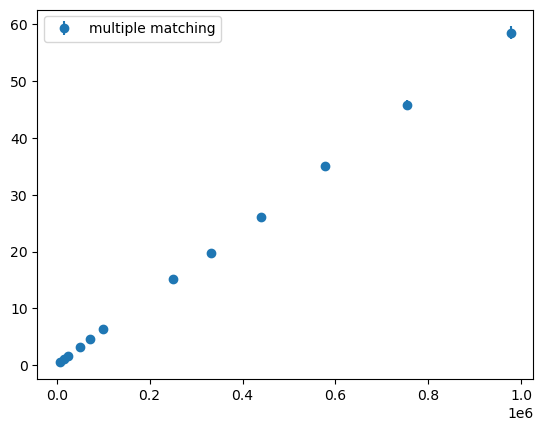

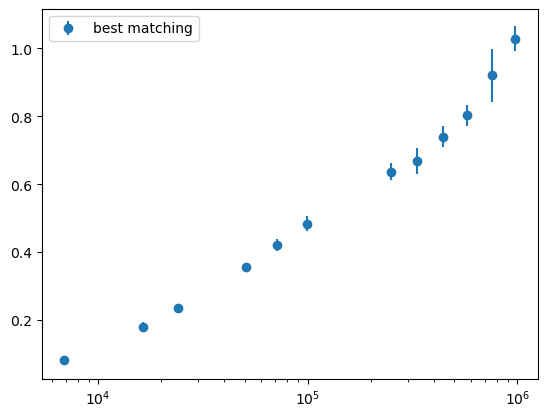

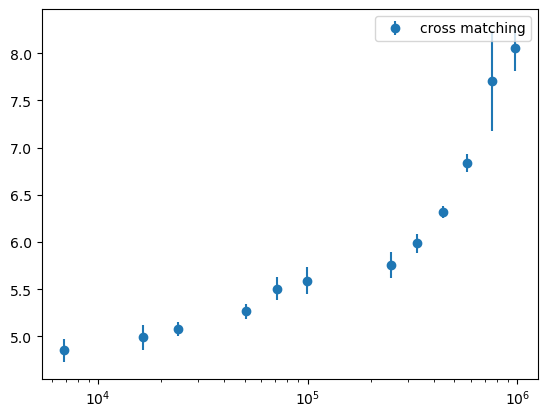

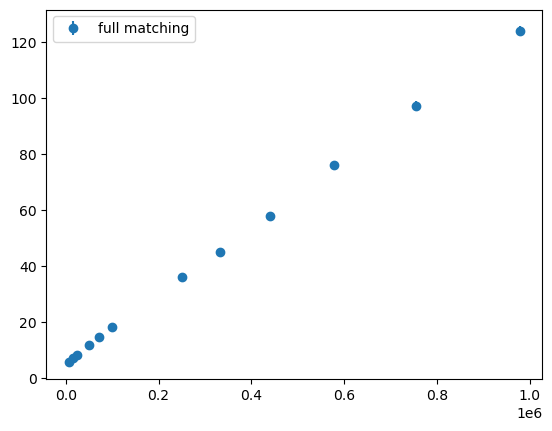

mean
[124.05697803  97.32272504  75.97083598  58.11456271  45.08711507
  36.07320572  18.43198064  14.91501313  11.83406994   8.31416527
   7.23117085   5.88222787]
var
[1.53242428 1.64676181 1.3242852  0.53314015 0.46846094 0.87849591
 0.40201363 0.27071476 0.07434255 0.11296761 0.18320903 0.11088078]


In [5]:
plt.errorbar(size_halo, mean_time_halo_m, yerr=std_time_halo_m, fmt='o',label="multiple matching")
#plt.xscale("log")
plt.legend()
plt.show()
plt.errorbar(size_halo, mean_time_halo_b, yerr=std_time_halo_b, fmt='o',label="best matching")
plt.xscale("log")
plt.legend()
plt.show()
plt.errorbar(size_halo, mean_time_halo_c, yerr=std_time_halo_c, fmt='o',label="cross matching")
plt.legend()
plt.xscale("log")
plt.show()
plt.errorbar(size_halo, mean_time_halo, yerr=std_time_halo, fmt='o',label="full matching")
plt.legend()
#plt.xscale("log")
plt.show()
# O(n), teste de extremos muita incompletude e pureza

mean_time_halo = np.array(mean_time_halo)
std_time_halo = np.array(std_time_halo)
print("mean")
print(mean_time_halo)
print("var")
print(std_time_halo)

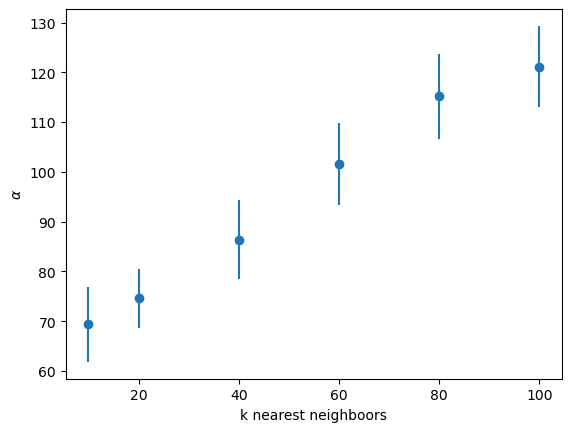

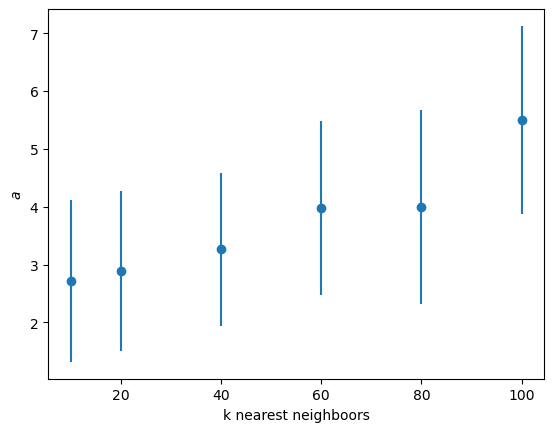

In [6]:
plt.errorbar(knearests, alphas*100, yerr=alphas_err*100, fmt='o')
plt.xlabel("k nearest neighboors")
plt.ylabel(r"$\alpha$")
plt.savefig(r"alpha_x_k.pdf")
plt.show()

plt.errorbar(knearests, a_s*100, yerr=a_s_err*100, fmt='o')
plt.xlabel("k nearest neighboors")
plt.ylabel(r"$a$")
plt.savefig(r"a_x_k.pdf")
plt.show()

In [7]:
a

NameError: name 'a' is not defined

In [ ]:
min_rich = [5, 7, 9, 10, 12, 14, 15, 17,  20, 22, 25, 30]
mean_time_cluster_m = []
mean_time_cluster_b = []
mean_time_cluster_c = []
mean_time_cluster = []
std_time_cluster_m  = []
std_time_cluster_b  = []
std_time_cluster_c  = []
std_time_cluster = []
size_cluster = []

# Using the same coordinate/property maps defined in your snippet
halo_coordinates = {"RA":"ra_true" , "DEC":"dec_true" , "z":"redshift_true", "ID":"ids"}
halo_properties  = {"halo_mass":"mass","halo_id":"halo_id"}

detections_coordinates = {"RA":"ra" , "DEC":"dec" , "z":"redshift"}
detections_properties  = {"richness":"R" , "redshift_err":"z_err" , "richness_err":"R_err","cluster_id":"cluster_id"}

# Assuming min_richness is your new list of thresholds
for richness_val in min_rich:
    # Filter the detection catalog (redmapper) by richness
    reduced_clusters = table_redmapper[table_redmapper['richness'] >= richness_val]
    size_cluster.append(len(reduced_clusters['richness']))

    # Initialize SkyMatch with Clusters as the Query Data
    clusters = sky_match.SkyMatch(query_data=reduced_clusters, 
                                  query_coordinates=detections_coordinates,
                                  match_data=table_halos,
                                  match_coordinates=halo_coordinates)

    halos = clusters.invert_query_match()
    time_match_m = []
    time_match_b = []
    time_match_c = []
    time_match   = []

    for i in range(5):
        start = time.perf_counter()
        
        # --- Part M: Initial Match ---
        start_m = time.perf_counter()
        clusters_matched = clusters.match_2d(cosmo, 100, distance_method=sky_match.DistanceMethod.QUERY_RADIUS)
        end_m = time.perf_counter()        
        time_match_m.append(end_m - start_m) 

        # --- Part B: Selection (Best Halo for each Cluster) ---
        mask_clusters = clusters_matched.filter_mask_by_redshift_proximity(sigma_z=0.0, query_sigma_z_column='redshift_err') & clusters_matched.filter_mask_by_distance(1)

        start_b = time.perf_counter()
        # Note: We select the best halo based on mass for the given cluster
        unique_clusters = clusters_matched.select_best(mask=mask_clusters, 
                                                       selection_criteria=sky_match.SelectionCriteria.MORE_MASSIVE, 
                                                       more_massive_column='halo_mass')
        end_b = time.perf_counter()       
        time_match_b.append(end_b - start_b)

        # --- Part C: Cross-Match (Verification via Halos) ---
        start_c = time.perf_counter()
        halos_matched = halos.match_2d(cosmo, 100, distance_method=sky_match.DistanceMethod.MATCH_RADIUS)
        mask_halos = halos_matched.filter_mask_by_redshift_proximity(sigma_z=0.0, match_sigma_z_column='redshift_err') & halos_matched.filter_mask_by_distance(1)

        unique_halos = halos_matched.select_best(mask=mask_halos, 
                                                 selection_criteria=sky_match.SelectionCriteria.MORE_MASSIVE, 
                                                 more_massive_column='richness')

        cross_indices = unique_clusters.get_cross_match_indices(unique_halos)
        
        end_c = time.perf_counter()
        time_match_c.append(end_c - start_c)

        end = time.perf_counter()
        time_match.append(end - start)

    # Statistical Aggregation
    time_match_m = np.array(time_match_m)
    time_match_b = np.array(time_match_b)
    time_match_c = np.array(time_match_c)
    time_match   = np.array(time_match)
    
    mean_time_cluster_m.append(np.mean(time_match_m))
    std_time_cluster_m.append(np.std(time_match_m))

    mean_time_cluster_b.append(np.mean(time_match_b))
    std_time_cluster_b.append(np.std(time_match_b))

    mean_time_cluster_c.append(np.mean(time_match_c))
    std_time_cluster_c.append(np.std(time_match_c))

    mean_time_cluster.append(np.mean(time_match))
    std_time_cluster.append(np.std(time_match))

# Final Conversion to Numpy Arrays
mean_time_cluster_m = np.array(mean_time_cluster_m)
std_time_cluster_m = np.array(std_time_cluster_m)

mean_time_cluster_b = np.array(mean_time_cluster_b)
std_time_cluster_b = np.array(std_time_cluster_b)

mean_time_cluster_c = np.array(mean_time_cluster_c)
std_time_cluster_c = np.array(std_time_cluster_c)

size_cluster = np.array(size_cluster)

In [ ]:
plt.errorbar(size_cluster, mean_time_cluster_m, yerr=std_time_halo_m, fmt='o', label="multiple matching")
plt.legend()
plt.xscale("log")
plt.show()
plt.errorbar(size_cluster, mean_time_cluster_b, yerr=std_time_halo_m, fmt='o', label="best matching")
plt.legend()
plt.xscale("log")
plt.show()
plt.errorbar(size_cluster, mean_time_cluster_c, yerr=std_time_halo_m, fmt='o', label="cross matching")
plt.legend()
plt.xscale("log")
plt.show()
plt.errorbar(size_cluster, mean_time_cluster, yerr=std_time_halo_m, fmt='o', label="full matching")
plt.legend()
plt.xscale("log")
plt.show()